# Comprensión de las características para el diseño de entradas en IDS

Ayuda a decidir **qué datos deben introducirse en el modelo IDS (AE + LSTM + CNN)**.

- Analizar la calidad de las características sin procesar (datos faltantes, varianza, correlación, solapamiento)
- Estimar qué características distinguen entre el comportamiento normal y los ataques a un nivel básico
- Crear una tabla transparente de «conservar / revisar / descartar» a partir de señales extraídas exclusivamente del conjunto de datos
- Exportar tablas y gráficos reutilizables para las decisiones de preprocesamiento


In [2]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

SEED = 42
np.random.seed(SEED)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


def detect_project_root(start: Path) -> Path:
    """Find the IDS project root robustly from notebook kernels."""
    start = start.resolve()

    def looks_like_ids_root(p: Path) -> bool:
        return (p / "data/processed").exists() and (p / "notebooks").exists() and (p / "src").exists()

    for p in [start, *start.parents]:
        if looks_like_ids_root(p):
            return p

    for p in [start, *start.parents]:
        candidate = p / "ids"
        if looks_like_ids_root(candidate):
            return candidate

    raise FileNotFoundError(
        f"Could not locate IDS project root from cwd={start}. "
        "Expected a directory containing data/processed, notebooks, and src."
    )


ROOT = detect_project_root(Path.cwd())
print(f"Resolved project root: {ROOT}")

DATASET_CONFIGS = {
    "UNSW": {
        "train_path": ROOT / "data/processed/UNSW-NB15/splits/train.csv",
        "val_path": ROOT / "data/processed/UNSW-NB15/splits/validation.csv",
        "test_path": ROOT / "data/processed/UNSW-NB15/splits/test.csv",
        "loader": pd.read_csv,
        "label_col": "attack_cat",
        "normal_label": "Normal",
        "drop_cols": ["attack_cat", "label", "id"],
        "out_fig_dir": ROOT / "reports/figures/unsw/feature_understanding",
        "out_tbl_dir": ROOT / "reports/metrics/unsw/feature_understanding",
    },
    "CIC": {
        "train_path": ROOT / "data/processed/CIC-IDS2017/splits/train/data.parquet",
        "val_path": ROOT / "data/processed/CIC-IDS2017/splits/val/data.parquet",
        "test_path": ROOT / "data/processed/CIC-IDS2017/splits/test/data.parquet",
        "loader": pd.read_parquet,
        "label_col": "attack_type",
        "normal_label": "BENIGN",
        "drop_cols": ["Label", "attack_label", "attack_type", "source_file"],
        "out_fig_dir": ROOT / "reports/figures/cic/feature_understanding",
        "out_tbl_dir": ROOT / "reports/metrics/cic/feature_understanding",
    },
}


def ensure_dirs(cfg: dict) -> None:
    cfg["out_fig_dir"].mkdir(parents=True, exist_ok=True)
    cfg["out_tbl_dir"].mkdir(parents=True, exist_ok=True)


def hist_overlap(a: np.ndarray, b: np.ndarray, bins: int = 40) -> float:
    if len(a) == 0 or len(b) == 0:
        return np.nan
    low = np.nanpercentile(np.concatenate([a, b]), 1)
    high = np.nanpercentile(np.concatenate([a, b]), 99)
    if not np.isfinite(low) or not np.isfinite(high) or low == high:
        return 1.0
    edges = np.linspace(low, high, bins + 1)
    ha, _ = np.histogram(a, bins=edges)
    hb, _ = np.histogram(b, bins=edges)
    pa = ha / max(ha.sum(), 1)
    pb = hb / max(hb.sum(), 1)
    return float(np.minimum(pa, pb).sum())


def single_feature_separability(x: np.ndarray, y: np.ndarray) -> float:
    if np.nanstd(x) == 0:
        return 0.0
    auc = roc_auc_score(y, x)
    return float(abs(auc - 0.5) * 2.0)


print("Dataset-only feature understanding setup ready.")

Resolved project root: /home/freuer/Documents/projects/ai/ids
Dataset-only feature understanding setup ready.


In [3]:
# Choose dataset: "UNSW" or "CIC"
DATASET = "UNSW"
assert DATASET in DATASET_CONFIGS, f"Unsupported DATASET={DATASET}"

cfg = DATASET_CONFIGS[DATASET]
ensure_dirs(cfg)

print(f"Dataset: {DATASET}")
print(f"Train file: {cfg['train_path']}")
print(f"Figures out: {cfg['out_fig_dir']}")
print(f"Tables out:  {cfg['out_tbl_dir']}")

Dataset: UNSW
Train file: /home/freuer/Documents/projects/ai/ids/data/processed/UNSW-NB15/splits/train.csv
Figures out: /home/freuer/Documents/projects/ai/ids/reports/figures/unsw/feature_understanding
Tables out:  /home/freuer/Documents/projects/ai/ids/reports/metrics/unsw/feature_understanding


## Caracteristicas en crudo

El modelo carga la división de datos, separa las etiquetas de las características de entrada de los candidatos y resume la huella numérica y categórica.

Esto determina el tamaño y la complejidad iniciales del espacio de características antes de aplicar cualquier filtro.

In [4]:
train_df = cfg["loader"](cfg["train_path"])
val_df = cfg["loader"](cfg["val_path"])
test_df = cfg["loader"](cfg["test_path"])

label_col = cfg["label_col"]
normal_label = cfg["normal_label"]
drop_cols = cfg["drop_cols"]

X_train = train_df.drop(columns=drop_cols, errors="ignore")
X_val = val_df.drop(columns=drop_cols, errors="ignore")
X_test = test_df.drop(columns=drop_cols, errors="ignore")

y_raw = train_df[label_col]
y_bin = (y_raw != normal_label).astype(int).to_numpy()

raw_numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
raw_categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Train rows: {len(train_df):,} | Val rows: {len(val_df):,} | Test rows: {len(test_df):,}")
print(f"Raw feature count: {X_train.shape[1]}")
print(f"Numeric features: {len(raw_numeric_cols)}")
print(f"Categorical features: {len(raw_categorical_cols)}")

if raw_categorical_cols:
    cat_cardinality = X_train[raw_categorical_cols].nunique(dropna=False).sort_values(ascending=False)
    display(cat_cardinality.head(15).to_frame("unique_values"))

Train rows: 113,921 | Val rows: 16,275 | Test rows: 32,549
Raw feature count: 42
Numeric features: 39
Categorical features: 3


,unique_values
proto,133
service,13
state,9


- Un gran número de características categóricas o una cardinalidad elevada implican un diseño de codificación más complejo.
- Un gran volumen de datos numéricos con pocas filas aumenta el riesgo de sobreajuste.
- Este inventario define el alcance de las etapas de reducción y priorización que se describen a continuación.

## Redundancia y señales con poca información

Identifica pares de características fuertemente correlacionadas y columnas con baja varianza.

Esto permite identificar las dimensiones de entrada que son redundantes o que probablemente tengan una contribución escasa.

In [4]:
# Correlation and low-variance diagnostics on numeric train features
numeric_df = X_train[raw_numeric_cols].copy()

corr = numeric_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

corr_rows = []
for col in upper.columns:
    for idx, val in upper[col].dropna().items():
        if val >= 0.90:
            corr_rows.append({"feature_a": idx, "feature_b": col, "abs_corr": float(val)})

high_corr_df = pd.DataFrame(corr_rows).sort_values("abs_corr", ascending=False) if corr_rows else pd.DataFrame(columns=["feature_a", "feature_b", "abs_corr"])

low_var = numeric_df.var().sort_values()
low_var_df = low_var.reset_index()
low_var_df.columns = ["feature", "variance"]

corr_out = cfg["out_tbl_dir"] / "high_correlation_pairs.csv"
var_out = cfg["out_tbl_dir"] / "low_variance_features.csv"
high_corr_df.to_csv(corr_out, index=False)
low_var_df.to_csv(var_out, index=False)

print("Top correlation pairs (>=0.90):")
display(high_corr_df.head(20))
print("Lowest variance features:")
display(low_var_df.head(20))
print(f"Saved: {corr_out}")
print(f"Saved: {var_out}")

Top correlation pairs (>=0.90):


,feature_a,feature_b,abs_corr
9,is_ftp_login,ct_ftp_cmd,0.999127
5,dbytes,dloss,0.996759
3,sbytes,sloss,0.996450
4,dpkts,dloss,0.980528
1,dpkts,dbytes,0.974730
6,swin,dwin,0.974127
2,spkts,sloss,0.971474
0,spkts,sbytes,0.963421
11,sinpkt,is_sm_ips_ports,0.937382
7,tcprtt,synack,0.936394


Lowest variance features:


,feature,variance
0,ackdat,0.002847
1,synack,0.003953
2,is_sm_ips_ports,0.004126
3,tcprtt,0.011547
4,is_ftp_login,0.015046
5,ct_ftp_cmd,0.015089
6,ct_flw_http_mthd,0.323422
7,trans_depth,0.596701
8,ct_state_ttl,0.926877
9,ct_dst_sport_ltm,5.035469


Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/unsw/feature_understanding/high_correlation_pairs.csv
Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/unsw/feature_understanding/low_variance_features.csv


- Los pares altamente correlacionados son candidatos para la selección agrupada.
- Las características con muy baja varianza suelen poder eliminarse sin pérdida de señal.
- Este bloque reduce el espacio de características antes de la puntuación de estabilidad/separabilidad.

## Correlación

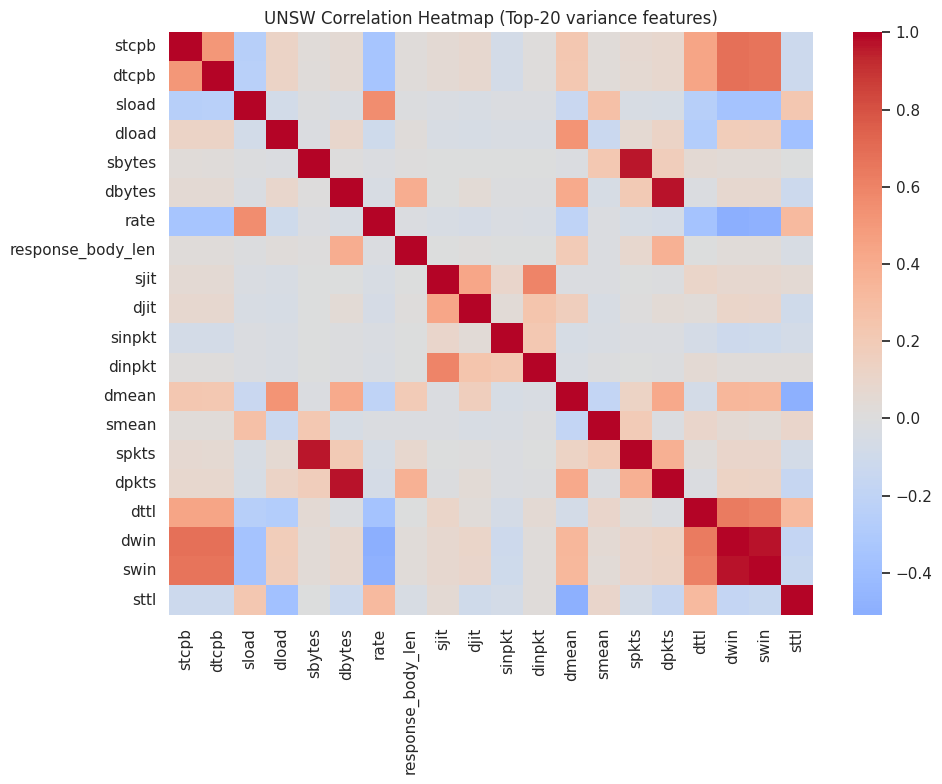

Saved: /home/freuer/Documents/projects/ai/ids/reports/figures/unsw/feature_understanding/correlation_heatmap_top20.png


In [5]:
# Optional quick heatmap using top-20 high variance features
heatmap_features = numeric_df.var().sort_values(ascending=False).head(20).index.tolist()
if heatmap_features:
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_df[heatmap_features].corr(), cmap="coolwarm", center=0)
    plt.title(f"{DATASET} Correlation Heatmap (Top-20 variance features)")
    plt.tight_layout()
    fig_out = cfg["out_fig_dir"] / "correlation_heatmap_top20.png"
    plt.savefig(fig_out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_out}")

- Los bloques densos del mismo color indican grupos con un alto grado de redundancia.
- Selecciona entre uno y dos representantes de cada grupo para el primer contrato.
- Documenta los motivos de la eliminación de características.

## Calidad de las caracteristicas

Implementa estadisticas de calidad por cada caracteristicas

Los indicadores de calidad sirven de guía para las decisiones iniciales de exclusión o revisión antes de proceder a una evaluación más exhaustiva.

In [6]:
# Data-quality summary table (dataset-only)
missing_ratio = numeric_df.isna().mean()
variance = numeric_df.var()

quality_df = pd.DataFrame(
    {
        "feature": raw_numeric_cols,
        "missing_ratio": [float(missing_ratio.get(f, np.nan)) for f in raw_numeric_cols],
        "variance": [float(variance.get(f, np.nan)) for f in raw_numeric_cols],
    }
)

quality_out = cfg["out_tbl_dir"] / "feature_quality_summary.csv"
quality_df.sort_values(["missing_ratio", "variance"], ascending=[False, True]).to_csv(quality_out, index=False)
display(quality_df.sort_values(["missing_ratio", "variance"], ascending=[False, True]).head(20))
print(f"Saved: {quality_out}")

,feature,missing_ratio,variance
22,ackdat,0.0,0.002847
21,synack,0.0,0.003953
38,is_sm_ips_ports,0.0,0.004126
20,tcprtt,0.0,0.011547
33,is_ftp_login,0.0,0.015046
34,ct_ftp_cmd,0.0,0.015089
35,ct_flw_http_mthd,0.0,0.323422
25,trans_depth,0.0,0.596701
28,ct_state_ttl,0.0,0.926877
31,ct_dst_sport_ltm,0.0,5.035469


Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/unsw/feature_understanding/feature_quality_summary.csv


- Un alto índice de datos faltantes y una baja varianza son indicadores de que es probable que esos datos deban descartarse.
- Las características de calidad aceptable deben pasar a las comprobaciones de estabilidad y separabilidad.
- Conserva esta tabla como justificación de las decisiones tomadas en la política de preprocesamiento.

## Estabilidad en los splits

Una caracteristica puede parecer sólida en train, pero seguir siendo arriesgada si no se mantiene estable en las divisiones.

In [7]:
def ks_statistic(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) == 0 or len(b) == 0:
        return np.nan
    a = np.sort(a)
    b = np.sort(b)
    vals = np.sort(np.concatenate([a, b]))
    cdf_a = np.searchsorted(a, vals, side="right") / len(a)
    cdf_b = np.searchsorted(b, vals, side="right") / len(b)
    return float(np.max(np.abs(cdf_a - cdf_b)))


stability_rows = []
for feat in raw_numeric_cols:
    tr = X_train[feat].dropna().to_numpy(dtype=float)
    va = X_val[feat].dropna().to_numpy(dtype=float)
    te = X_test[feat].dropna().to_numpy(dtype=float)
    ks_tv = ks_statistic(tr, va)
    ks_tt = ks_statistic(tr, te)
    max_ks = np.nanmax([ks_tv, ks_tt])
    stability_rows.append(
        {
            "feature": feat,
            "ks_train_val": ks_tv,
            "ks_train_test": ks_tt,
            "stability_score": float(1.0 - max_ks) if np.isfinite(max_ks) else np.nan,
        }
    )

stability_df = pd.DataFrame(stability_rows).sort_values("stability_score", ascending=False)
stability_out = cfg["out_tbl_dir"] / "feature_stability_scores.csv"
stability_df.to_csv(stability_out, index=False)

display(stability_df.head(20))
print(f"Saved: {stability_out}")

,feature,ks_train_val,ks_train_test,stability_score
33,is_ftp_login,0.000343,0.000250,0.999657
34,ct_ftp_cmd,0.000360,0.000268,0.999640
38,is_sm_ips_ports,0.000211,0.000672,0.999328
31,ct_dst_sport_ltm,0.001739,0.001414,0.998261
6,sttl,0.001329,0.002214,0.997786
16,swin,0.002433,0.002854,0.997146
37,ct_srv_dst,0.002877,0.001996,0.997123
28,ct_state_ttl,0.002213,0.002911,0.997089
26,response_body_len,0.001675,0.003028,0.996972
19,dwin,0.003495,0.003381,0.996505


Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/unsw/feature_understanding/feature_stability_scores.csv


- Una puntuación alta en estabilidad indica que el comportamiento es coherente en todas las divisiones.
- Una puntuación baja en estabilidad implica que hay que actuar con especial precaución, incluso si la separabilidad es alta.
- Se deben priorizar las características que presenten tanto una buena estabilidad como métricas de calidad aceptables.

## Clusters de redundancia

Agrupa características altamente correlacionadas en clústeres de redundancia ligeros.

Los clústeres ayudan a definir características representativas y a reducir la amplitud de las entradas para la primera iteración del modelo.
ocho clústeres de redundancia.

In [8]:
corr_thr = 0.90
adj = {f: set() for f in raw_numeric_cols}
for _, r in high_corr_df.iterrows():
    a, b, c = r["feature_a"], r["feature_b"], r["abs_corr"]
    if c >= corr_thr:
        adj[a].add(b)
        adj[b].add(a)

visited = set()
clusters = []
for f in raw_numeric_cols:
    if f in visited:
        continue
    stack = [f]
    comp = []
    while stack:
        cur = stack.pop()
        if cur in visited:
            continue
        visited.add(cur)
        comp.append(cur)
        stack.extend(list(adj[cur] - visited))
    if len(comp) > 1:
        clusters.append(sorted(comp))

cluster_rows = []
for i, comp in enumerate(sorted(clusters, key=len, reverse=True), 1):
    cluster_rows.append({"cluster_id": i, "size": len(comp), "features": ", ".join(comp)})

cluster_df = pd.DataFrame(cluster_rows)
cluster_out = cfg["out_tbl_dir"] / "feature_redundancy_clusters.csv"
cluster_df.to_csv(cluster_out, index=False)
display(cluster_df.head(20))
print(f"Saved: {cluster_out}")

,cluster_id,size,features
0,1,3,"sbytes, sloss, spkts"
1,2,3,"dbytes, dloss, dpkts"
2,3,3,"ackdat, synack, tcprtt"
3,4,2,"is_sm_ips_ports, sinpkt"
4,5,2,"dwin, swin"
5,6,2,"ct_srv_dst, ct_srv_src"
6,7,2,"ct_ftp_cmd, is_ftp_login"


Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/unsw/feature_understanding/feature_redundancy_clusters.csv


- Los clústeres grandes indican una gran redundancia y son candidatos a la compresión.
- Selecciona valores representativos basándote en la separabilidad, la estabilidad y la calidad.
- Conserva las exportaciones de los clústeres como justificación de las decisiones de poda de características.

## Separabilidad univariante

Calcula en qué medida cada característica numérica distingue entre «Normal» y «Ataque» en los datos de entrenamiento.

Esto proporciona una clasificación preliminar de la prioridad de las señales antes de la importancia de las características basada en el modelo.

In [9]:
# Lightweight separability diagnostics (fast, no heavy feature selectors)
metric_rows = []

for feat in raw_numeric_cols:
    s = X_train[feat].to_numpy(dtype=float)
    if np.nanstd(s) == 0:
        continue

    # Fill NaN only for metric computation
    s_filled = pd.Series(s).fillna(np.nanmedian(s)).to_numpy(dtype=float)
    sep = single_feature_separability(s_filled, y_bin)

    normal_vals = s_filled[y_bin == 0]
    attack_vals = s_filled[y_bin == 1]
    overlap = hist_overlap(normal_vals, attack_vals)

    metric_rows.append(
        {
            "feature": feat,
            "separability_score": sep,
            "class_overlap_score": overlap,
            "variance": float(np.nanvar(s_filled)),
            "missing_ratio": float(np.mean(np.isnan(s))),
        }
    )

metrics_df = pd.DataFrame(metric_rows)
metrics_df = metrics_df.sort_values(["separability_score", "class_overlap_score"], ascending=[False, True])

metrics_out = cfg["out_tbl_dir"] / "feature_lightweight_metrics.csv"
metrics_df.to_csv(metrics_out, index=False)
print(f"Saved: {metrics_out}")
display(metrics_df.head(20))

Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/unsw/feature_understanding/feature_lightweight_metrics.csv


,feature,separability_score,class_overlap_score,variance,missing_ratio
6,sttl,0.643798,0.342112,1.155338e+04,0.0
28,ct_state_ttl,0.626586,0.306918,9.268690e-01,0.0
9,dload,0.552750,0.584639,8.769334e+12,0.0
24,dmean,0.395909,0.576706,8.752602e+04,0.0
29,ct_dst_ltm,0.347116,0.645081,1.778723e+01,0.0
37,ct_srv_dst,0.346784,0.611940,4.160203e+01,0.0
27,ct_srv_src,0.284830,0.696444,4.293750e+01,0.0
4,dbytes,0.276027,0.855316,3.206404e+10,0.0
36,ct_src_ltm,0.269168,0.704562,2.478385e+01,0.0
2,dpkts,0.266545,0.736629,1.861461e+04,0.0


- Una alta separabilidad y un bajo solapamiento indican que las características son buenas candidatas.
- Utiliza la separabilidad junto con la estabilidad y la calidad, no de forma aislada.
- Evita seleccionar características inestables, incluso cuando la separabilidad sea alta.

## Ruta de preprocesamiento

Combina calidad, estabilidad y capacidad de separación en «mantener/revisar/eliminar» y exporta un contrato de preprocesamiento inicial.

In [10]:
# Build keep/review/drop recommendation table and initial contract
reco_df = metrics_df.merge(stability_df[["feature", "stability_score", "ks_train_val", "ks_train_test"]], on="feature", how="left")

reco_df["recommendation"] = "review"
reco_df.loc[
    (reco_df["separability_score"] >= 0.20)
    & (reco_df["class_overlap_score"] <= 0.60)
    & (reco_df["missing_ratio"] <= 0.40)
    & (reco_df["stability_score"] >= 0.70),
    "recommendation",
] = "keep"

reco_df.loc[
    (reco_df["separability_score"] < 0.08)
    | (reco_df["class_overlap_score"] > 0.85)
    | (reco_df["missing_ratio"] > 0.75)
    | (reco_df["variance"] < 1e-8)
    | (reco_df["stability_score"] < 0.40),
    "recommendation",
] = "drop"

# Simple first-pass preprocessing hints
reco_df["impute_hint"] = np.where(reco_df["missing_ratio"] > 0.05, "median", "none")
reco_df["scale_hint"] = np.where(reco_df["variance"] > 0, "robust_scale", "none")
reco_df["log_hint"] = np.where(reco_df["class_overlap_score"] > 0.75, "review_log_transform", "none")
reco_df["encode_hint"] = "numeric"

recommendation_out = cfg["out_tbl_dir"] / "feature_recommendations.csv"
contract_out = cfg["out_tbl_dir"] / "feature_contract_initial.csv"

ordered = reco_df.sort_values(["recommendation", "separability_score", "stability_score"], ascending=[True, False, False])
ordered.to_csv(recommendation_out, index=False)
ordered[[
    "feature",
    "recommendation",
    "separability_score",
    "stability_score",
    "missing_ratio",
    "variance",
    "impute_hint",
    "scale_hint",
    "log_hint",
    "encode_hint",
]].to_csv(contract_out, index=False)

summary = ordered["recommendation"].value_counts().rename_axis("recommendation").reset_index(name="count")
display(summary)
display(ordered.head(30))
print(f"Saved: {recommendation_out}")
print(f"Saved: {contract_out}")

,recommendation,count
0,drop,18
1,review,15
2,keep,6


,feature,separability_score,class_overlap_score,variance,missing_ratio,stability_score,ks_train_val,ks_train_test,recommendation,impute_hint,scale_hint,log_hint,encode_hint
7,dbytes,0.276027,0.855316,3.206404e+10,0.0,0.993481,0.006519,0.003663,drop,none,robust_scale,review_log_transform,numeric
17,sbytes,0.167086,0.851296,4.276943e+10,0.0,0.991707,0.008293,0.004460,drop,none,robust_scale,review_log_transform,numeric
19,ct_dst_sport_ltm,0.159575,0.856668,5.035425e+00,0.0,0.998261,0.001739,0.001414,drop,none,robust_scale,review_log_transform,numeric
22,sinpkt,0.138466,0.906212,1.626141e+07,0.0,0.994068,0.005932,0.005052,drop,none,robust_scale,review_log_transform,numeric
23,dur,0.119687,0.855379,2.665964e+01,0.0,0.994938,0.003391,0.005062,drop,none,robust_scale,review_log_transform,numeric
25,djit,0.113827,0.906404,2.015418e+07,0.0,0.994205,0.004360,0.005795,drop,none,robust_scale,review_log_transform,numeric
27,trans_depth,0.101116,0.898635,5.966959e-01,0.0,0.995783,0.000334,0.004217,drop,none,robust_scale,review_log_transform,numeric
28,ct_flw_http_mthd,0.100532,0.898047,3.234193e-01,0.0,0.995765,0.000377,0.004235,drop,none,robust_scale,review_log_transform,numeric
29,swin,0.077313,0.922535,1.319772e+04,0.0,0.997146,0.002433,0.002854,drop,none,robust_scale,review_log_transform,numeric
30,dwin,0.057048,0.942817,1.349202e+04,0.0,0.996505,0.003495,0.003381,drop,none,robust_scale,review_log_transform,numeric


Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/unsw/feature_understanding/feature_recommendations.csv
Saved: /home/freuer/Documents/projects/ai/ids/reports/metrics/unsw/feature_understanding/feature_contract_initial.csv


- `keep` Candidatos a mantenerse.
- `review` Necesitan procesamiento adicional.
- `feature_contract_initial.csv` is the operational handoff to preprocessing implementation.